# AEP Load Forecasting Models

This notebook develops forecasting models for hourly AEP electricity demand using the cleaned load-weather dataset prepared in the pipeline notebook. The workflow includes feature engineering, baseline forecasting, machine learning models, and forecast evaluation.

## 1. Project Goal

The objective is to model next-hour electricity demand and evaluate how historical load patterns and weather conditions improve forecast accuracy.

## 2. Load Cleaned Dataset

Read the prepared clean base dataset from the preprocessing notebook and validate the loaded data.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-whitegrid')

input_path = '../data/aep_load_weather_hourly_dataset.csv'
market_df = pd.read_csv(input_path)
market_df['datetime'] = pd.to_datetime(market_df['datetime'], errors='coerce')
market_df = market_df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

print('Loaded dataset rows:', len(market_df))
print(market_df.dtypes)
print(market_df.head())

Loaded dataset rows: 11662
datetime          datetime64[ns]
load_mw                  float64
temperature_2m           float64
sin_hour                 float64
cos_hour                 float64
dtype: object
             datetime    load_mw  temperature_2m  sin_hour  cos_hour
0 2024-01-01 00:00:00  13510.539            -0.4  0.000000  1.000000
1 2024-01-01 01:00:00  13392.585            -0.6  0.258819  0.965926
2 2024-01-01 02:00:00  13317.742            -0.6  0.500000  0.866025
3 2024-01-01 03:00:00  13242.742            -0.6  0.707107  0.707107
4 2024-01-01 04:00:00  13392.619            -0.4  0.866025  0.500000


/var/folders/yd/h0rh3srn2634qw945z8lpjkr0000gq/T/ipykernel_11131/3027559842.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


## 3. Feature Engineering

Create temporal features, cyclical hour encoding, lag values, rolling statistics, and a nonlinear temperature term. These derived features are common in operational load forecasting models.

This setup defines the target as next-hour AEP load, so all lag and rolling features are based only on information available before the forecasted hour.

In [60]:
market_df['hour'] = market_df['datetime'].dt.hour
market_df['dayofweek'] = market_df['datetime'].dt.dayofweek
market_df['month'] = market_df['datetime'].dt.month
market_df['is_weekend'] = (market_df['dayofweek'] >= 5).astype(int)
market_df['is_peak_hour'] = market_df['hour'].between(7, 22).astype(int)

market_df['lag_1'] = market_df['load_mw'].shift(1)
market_df['lag_24'] = market_df['load_mw'].shift(24)
market_df['lag_168'] = market_df['load_mw'].shift(168)
market_df['load_ramp_1'] = market_df['load_mw'] - market_df['lag_1']

market_df['rolling_mean_24'] = market_df['load_mw'].shift(1).rolling(window=24).mean()
market_df['rolling_std_24'] = market_df['load_mw'].shift(1).rolling(window=24).std()

market_df['temp_sq'] = market_df['temperature_2m'] ** 2
market_df['target_load_mw'] = market_df['load_mw'].shift(-1)

feature_cols_for_na = [
    'lag_1', 'lag_24', 'lag_168', 'load_ramp_1',
    'rolling_mean_24', 'rolling_std_24', 'target_load_mw'
]
market_df = market_df.dropna(subset=feature_cols_for_na).reset_index(drop=True)
print('Rows after feature engineering:', len(market_df))
print(market_df[['datetime', 'hour', 'dayofweek', 'month', 'is_weekend', 'sin_hour', 'cos_hour', 'is_peak_hour', 'temperature_2m', 'temp_sq', 'lag_1', 'lag_24', 'lag_168', 'load_ramp_1', 'rolling_mean_24', 'rolling_std_24', 'target_load_mw']].head())

Rows after feature engineering: 11493
             datetime  hour  dayofweek  month  is_weekend  sin_hour  cos_hour  \
0 2024-01-08 00:00:00     0          0      1           0  0.000000  1.000000   
1 2024-01-08 01:00:00     1          0      1           0  0.258819  0.965926   
2 2024-01-08 02:00:00     2          0      1           0  0.500000  0.866025   
3 2024-01-08 03:00:00     3          0      1           0  0.707107  0.707107   
4 2024-01-08 04:00:00     4          0      1           0  0.866025  0.500000   

   is_peak_hour  temperature_2m  temp_sq      lag_1     lag_24    lag_168  \
0             0            -0.3     0.09  14832.815  14200.251  13510.539   
1             0            -1.9     3.61  14619.841  14030.158  13392.585   
2             0            -2.5     6.25  14607.270  13933.807  13317.742   
3             0            -3.3    10.89  14440.042  13853.914  13242.742   
4             0            -2.0     4.00  14471.726  13911.892  13392.619   

   load_ramp

## 4. Train/Test Split

Use a time-based split rather than a random split to preserve the forecasting timeline. The test set covers the most recent period, which is the realistic evaluation scenario for demand forecasting.

A random split would mix future observations into the training set and create an unrealistic forecasting evaluation. A time-based split keeps the test period as unseen future data.

In [61]:
cutoff_date = '2025-01-25 03:00:00'
train_df = market_df[market_df['datetime'] < cutoff_date].copy()
test_df = market_df[market_df['datetime'] >= cutoff_date].copy()

print('Cutoff date:', cutoff_date)
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train range:', train_df['datetime'].min(), 'to', train_df['datetime'].max())
print('Test range:', test_df['datetime'].min(), 'to', test_df['datetime'].max())

Cutoff date: 2025-01-25 03:00:00
Train rows: 9194
Test rows: 2299
Train range: 2024-01-08 00:00:00 to 2025-01-25 02:00:00
Test range: 2025-01-25 03:00:00 to 2025-04-30 22:00:00


## 5. Baseline Forecast

A persistence baseline predicts next-hour load using the current hour’s observed load. This simple benchmark is useful to compare against machine learning models.

In [62]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

baseline_df = test_df.copy()
baseline_df['persistence'] = baseline_df['load_mw']

baseline_df = baseline_df.dropna(subset=['persistence', 'target_load_mw'])

baseline_metrics = {
    'MAE': mae(baseline_df['target_load_mw'], baseline_df['persistence']),
    'RMSE': rmse(baseline_df['target_load_mw'], baseline_df['persistence']),
    'MAPE': mape(baseline_df['target_load_mw'], baseline_df['persistence'])
}

print('Persistence baseline metrics:')
print(baseline_metrics)

Persistence baseline metrics:
{'MAE': 301.6088464549804, 'RMSE': 384.72845277558804, 'MAPE': 1.9868780394114902}


## 6. ML Models

Train simple regression models on the engineered features. Compare Linear Regression, Random Forest, and XGBoost as a first modeling step.

Tree-based models often perform best in this setup, since they can capture nonlinear temperature effects and interactions between lagged load, calendar features, and recent load volatility.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

feature_columns = [
    'temperature_2m', 'temp_sq', 'sin_hour', 'cos_hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour',
    'lag_1', 'lag_24', 'lag_168', 'load_ramp_1', 'rolling_mean_24', 'rolling_std_24'
]

y_train = train_df['target_load_mw']
X_train = train_df[feature_columns]
y_test = test_df['target_load_mw']
X_test = test_df[feature_columns]

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
}

model_predictions = {}
model_metrics = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    model_predictions[name] = preds
    model_metrics[name] = {
        'MAE': mae(y_test, preds),
        'RMSE': rmse(y_test, preds),
        'MAPE': mape(y_test, preds)
    }

print('Model evaluation metrics:')
for name, metrics in model_metrics.items():
    print(name, metrics)

Model evaluation metrics:
Linear Regression {'MAE': 165.21914889687315, 'RMSE': 215.58007616560343, 'MAPE': 1.076836265431966}
Random Forest {'MAE': 149.16436335363204, 'RMSE': 196.18493243453685, 'MAPE': 0.9703789297653751}
XGBoost {'MAE': 127.87653322436387, 'RMSE': 165.6202100115846, 'MAPE': 0.8364733621848033}


## 7. Evaluation

Compare model performance using MAE, RMSE, and MAPE. These metrics reflect operational forecast quality for hourly demand planning.

In [64]:
results_df = pd.DataFrame(model_metrics).T
baseline_row = pd.Series(baseline_metrics, name='Persistence')
results_df = pd.concat([baseline_row.to_frame().T, results_df])
results_df['MAE_improvement_vs_baseline_%'] = (
    (baseline_metrics['MAE'] - results_df['MAE']) / baseline_metrics['MAE'] * 100
)
results_df.loc['Persistence', 'MAE_improvement_vs_baseline_%'] = 0.0
print(results_df)

                          MAE        RMSE      MAPE  \
Persistence        301.608846  384.728453  1.986878   
Linear Regression  165.219149  215.580076  1.076836   
Random Forest      149.164363  196.184932  0.970379   
XGBoost            127.876533  165.620210  0.836473   

                   MAE_improvement_vs_baseline_%  
Persistence                             0.000000  
Linear Regression                      45.220722  
Random Forest                          50.543770  
XGBoost                                57.601863  


## 8. Forecast Visualization

Plot actual versus predicted load for a recent period to inspect forecast behavior and identify periods of strong or weak performance.

All models capture the strong intraday load cycle, while the Random Forest model better tracks turning points and peak demand periods relative to the persistence baseline.

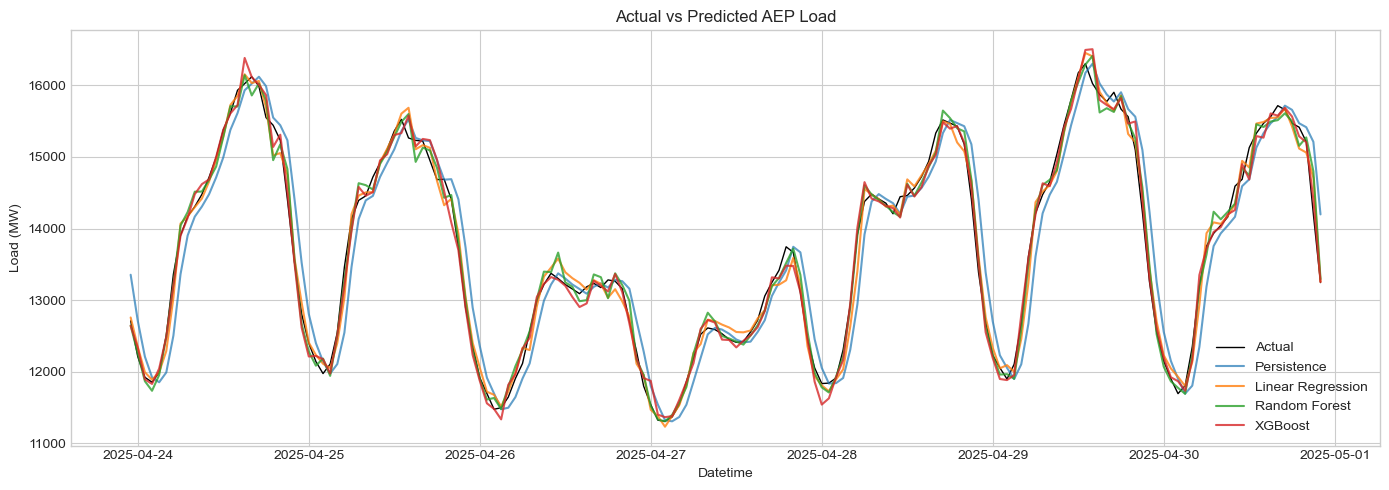

In [65]:
visual_df = test_df[['datetime', 'target_load_mw']].copy()
visual_df = visual_df.rename(columns={'target_load_mw': 'Actual'})
visual_df['Persistence'] = baseline_df['persistence']
for name, preds in model_predictions.items():
    visual_df[name] = preds

plot_window = 168
sample = visual_df.tail(plot_window)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['datetime'], sample['Actual'], label='Actual', color='black', linewidth=1)
ax.plot(sample['datetime'], sample['Persistence'], label='Persistence', alpha=0.7)
for name in model_predictions:
    ax.plot(sample['datetime'], sample[name], label=name, alpha=0.8)

ax.set_title('Actual vs Predicted AEP Load')
ax.set_xlabel('Datetime')
ax.set_ylabel('Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Operational Interpretation

Both machine learning models substantially outperform the persistence baseline across MAE, RMSE, and MAPE metrics. The Random Forest model achieves the strongest performance, suggesting that nonlinear interactions between weather conditions, cyclical time patterns, and historical load behavior improve short-term demand forecasting accuracy.

More accurate short-term forecasts can support generation scheduling, reserve planning, and operational risk management during periods of volatile demand.

## 10. Feature Importance

Inspect the Random Forest and XGBoost feature importances to understand which engineered demand drivers contribute most to next-hour load forecasting accuracy. Comparing both tree-based models helps validate whether the same demand signals are consistently important across different nonlinear learners.


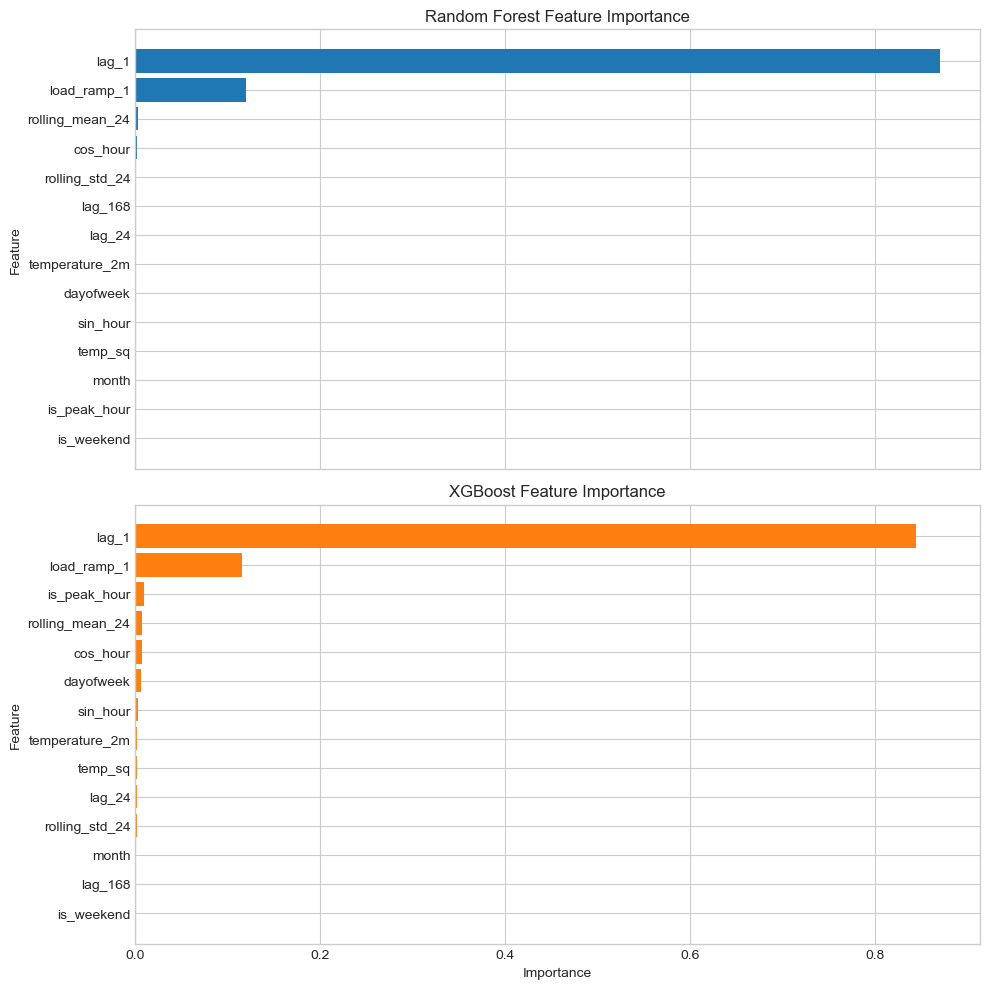

Random Forest top features:
            feature  importance
8             lag_1    0.870523
11      load_ramp_1    0.119577
12  rolling_mean_24    0.002263
3          cos_hour    0.001499
13   rolling_std_24    0.001015
10          lag_168    0.000913
9            lag_24    0.000816
0    temperature_2m    0.000734
4         dayofweek    0.000690
2          sin_hour    0.000662

XGBoost top features:
            feature  importance
8             lag_1    0.844925
11      load_ramp_1    0.114919
7      is_peak_hour    0.009718
12  rolling_mean_24    0.007203
3          cos_hour    0.006662
4         dayofweek    0.006042
2          sin_hour    0.002492
0    temperature_2m    0.002080
1           temp_sq    0.001671
9            lag_24    0.001469


In [67]:
rf_model = models['Random Forest']

rf_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_model = models['XGBoost']
xgb_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

axes[0].barh(rf_importance_df['feature'], rf_importance_df['importance'], color='tab:blue')
axes[0].invert_yaxis()
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_ylabel('Feature')

axes[1].barh(xgb_importance_df['feature'], xgb_importance_df['importance'], color='tab:orange')
axes[1].invert_yaxis()
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

print('Random Forest top features:')
print(rf_importance_df.head(10))
print('\nXGBoost top features:')
print(xgb_importance_df.head(10))


Both Random Forest and XGBoost identified short-term autoregressive behavior as the dominant driver of next-hour load forecasting performance. The previous hour load (lag_1) contributed over 84% of total feature importance across both models, indicating strong persistence in electricity demand patterns.

Recent load ramp behavior also contributed materially, while calendar and weather variables played a secondary but still meaningful role. This suggests that short-term grid demand dynamics are primarily governed by recent consumption behavior rather than exogenous weather variation over this forecasting horizon.